# FAO GAEZ Land Use Maps Generator
Some outputs from the original data are note ok, so these will be replaced using FAO GAEZ data, including:

|Crop|Reason|
|:---|:-----|
|Oil Palm | Land use raster wrong, missing important production zones like Indonesia|
|Tomatoes| SPAM yields overly high, distorting results for some countries |
|Potatoes| Same as tomatoes |
| Maize | Super high yields |
|Tobacco| High yields |

## Suitability Index Inventory
We start by generating a file with all the files we have

In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import rasterio
import importlib
from rasterio.warp import reproject
from rasterio.enums import Resampling
import geopandas as gpd

from sbtn_leaf.paths import data_path
import sbtn_leaf.map_plotting as mp
import sbtn_leaf.map_calculations as mc
import sbtn_leaf.cropcalcs as cropcalcs
import sbtn_leaf.RothC_Raster as rothc

project_root = Path.cwd().parents[1]   # adjust number
soc_raster_folder = project_root/"LEAFs/SOC/rasters/"
q_breaks = [0,10,30,50,70,90,110,200]

Could not determine dtype for column 1, falling back to string


In [2]:
files_folder = "../data/crops/FAO_GAEZ/SuitIndex"
files_prefix = "GAEZ-V5.RES05-SIX.HP0120.AGERA5.HIST."
files_extension = ".tif"
TEC_LOOKUP = {
    "HILM": "high_input_irrigated",
    "HRLM": "high_input_rainfed",
    "LILM": "low_input_irrigated",
    "LRLM": "low_input_rainfed",
}

IRR_LOOKUP = {
    "HILM": "irr",
    "HRLM": "rf",
    "LILM": "irr",
    "LRLM": "rf",
}

In [3]:
crop_index = pl.read_csv(data_path("crops", "FAO_GAEZ", "FAO_GAEZ_croplist.csv")).drop(["description", "index"]).rename({"caption":"crop_name", "code": "crop_code"})

In [4]:
crop_index.head()

crop_code,crop_name
str,str
"""ALF""","""Alfalfa"""
"""BAN""","""Banana"""
"""BRL""","""Barley"""
"""BSG""","""Biomass sorghum"""
"""BCH""","""Brachiaria"""


In [5]:
folder_path = data_path("crops", "FAO_GAEZ", "SuitIndex")

In [6]:
output_rows = []

for file in os.listdir(folder_path):
    if not file.lower().endswith(".tif"):  # skip not tif files
        continue

    filename = Path(file).stem
    file_path = str(folder_path / Path(file))
    parts = filename.split(".")
    if len(parts) < 2:
            continue
    
    crop_code = parts[-2].strip().upper()
    tech_code = parts[-1].strip().upper()

    output_rows.append({
        "filename": file,
        "filepath": file_path,
        "crop_code": crop_code,
        "tech_code": tech_code,
        "technology": TEC_LOOKUP.get(tech_code),
        "irrigation_practice": IRR_LOOKUP.get(tech_code)
    })

df = pl.DataFrame(output_rows)

# Attach crop names
df = df.join(
     other=crop_index,
     on="crop_code",
     how="left"
)

In [7]:
df.head(2)

filename,filepath,crop_code,tech_code,technology,irrigation_practice,crop_name
str,str,str,str,str,str,str
"""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""ALF""","""HILM""","""high_input_irrigated""","""irr""","""Alfalfa"""
"""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""ALF""","""HRLM""","""high_input_rainfed""","""rf""","""Alfalfa"""


Storing it

In [8]:
csv_out_path = project_root / "data" / "crops" / "FAO_GAEZ" / "fao_gaez_crop_suitindex_list.csv"

df.write_csv(
    str(csv_out_path),
    separator=";"
)

In [9]:
fao_gaez_crops = df["crop_name"].unique()

## Attaching to our analyzed crops

In [38]:
sbtn_crops = pl.read_excel(data_path("crops","FAO_GAEZ", "crops_file_index.xlsx"))

There a few crop names that need adjustment from FAO GAEZ

In [39]:
CROP_RENAME = {
    "Citrus": "Orange",
    "Sugar cane": "Sugarcane",
    "White potato": "Potato",
}

crop_renaming = pl.DataFrame(
    {"fao_gaez_name": ["Citrus","Sugar cane", "White potato"],
    "sbtn_name": ["Orange", "Sugarcane", "Potato"]}
)

Some don't have matches and are kept the same, including:
- Apples
- Grapes

Updating this couple of names

In [12]:
df = (
    df
    .join(
        crop_renaming,
        left_on="crop_name",
        right_on="fao_gaez_name",
        how="left"
    )
    .with_columns(
        pl.coalesce(["sbtn_name", "crop_name"]).alias("crop_name")
    ).drop("sbtn_name")
)

Now, we need only the high input ones

In [13]:
df = df.filter(pl.col("technology").is_in(["high_input_irrigated","high_input_rainfed"]))

Adding the suitability index file

In [15]:
sbtn_crops = sbtn_crops.join(
    other=df,
    how="left",
    on = ["crop_name", "irrigation_practice"]
)

In [16]:
sbtn_crops.head()

crop_name,crop_practice_string,crop_type,irrigation_practice,filename,filepath,crop_code,tech_code,technology,filename_right,filepath_right,crop_code_right,tech_code_right,technology_right
str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""Barley""","""irr_ron""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated"""
"""Barley""","""irr_roff""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated"""
"""Cabbage""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAB""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAB""","""HILM""","""high_input_irrigated"""
"""Carrot""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAR""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAR""","""HILM""","""high_input_irrigated"""
"""Cotton""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""COT""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""COT""","""HILM""","""high_input_irrigated"""


Eliminating apple and grapes

In [17]:
sbtn_crops = sbtn_crops.filter(pl.col("tech_code").is_not_null())

Eliminating duplicated _right columns

In [19]:
sbtn_crops = sbtn_crops.select(
    pl.all().exclude("^.*_right$")
)

## Creating land use maps

### LU Generating function

In [20]:
def create_lu_raster(
    input_fao_raster_path: str,
    output_folder: str,
    output_name: None | str = None,
    fao_raster_str_id: str = "GAEZ-V5.RES05-SIX.HP0120.AGERA5.HIST.",
    uhth_path: str = str(data_path("CountryLayers","soc_uht_map.tif")),
    fao_water: int = 9,
    fao_notsuitable: int = 8,
    fao_si_max: int = 7,
    resampling_method: Resampling = Resampling.mode,
):
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    # --- open base (target grid) ---
    with rasterio.open(uhth_path) as base:
        base_profile = base.profile.copy()
        base_crs = base.crs
        base_transform = base.transform
        base_shape = (base.height, base.width)
        base_nodata = base.nodata

    # --- open FAO raster (source grid) ---
    with rasterio.open(input_fao_raster_path) as fao:
        fao_crs = fao.crs
        fao_transform = fao.transform
        fao_data = fao.read(1)
        fao_nodata = fao.nodata

    # --- build binary on FAO grid ---
    suitable_mask = (
        (fao_data != fao_nodata)
        & (fao_data != fao_water)
        & (fao_data != fao_notsuitable)
        & (fao_data <= fao_si_max)   # <= is usually what you want
    )

    lu_src = np.where(suitable_mask, 1, 0).astype("uint8")

    # --- reproject/resample onto base grid ---
    lu_dst = np.full(base_shape, 0, dtype="uint8")  # binary output; choose 0 as background

    reproject(
        source=lu_src,
        destination=lu_dst,
        src_transform=fao_transform,
        src_crs=fao_crs,
        src_nodata=0,
        dst_transform=base_transform,
        dst_crs=base_crs,
        dst_nodata=0,
        resampling=resampling_method,
    )

    # --- construct output name ---
    if output_name is None:
        fname = Path(input_fao_raster_path).name
        lu_name = fname.split(fao_raster_str_id, 1)[1].rsplit(".tif", 1)[0]
        output_file = f"{lu_name}.tif"
    else:
        output_file = f"{output_name}.tif"

    output_path = f'{output_folder}/{output_file}'

    # --- update profile for binary output ---
    out_profile = base_profile.copy()
    out_profile.update(
        dtype="uint8",
        count=1,
        nodata=0,
        compress="lzw",
    )

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(lu_dst, 1)

    return str(output_path)


### Going through all the files in the excel

In [21]:
output_folder = str(data_path("land_use","FAO_GAEZ"))

In [ ]:
output_rows = []

for row in sbtn_crops.iter_rows(named=True):
    input_raster = row["filepath"]
    crop_name = row["crop_name"]
    practice_id = row["crop_practice_string"]

    output_name = f"lu_gaez_{crop_name}_{practice_id}"

    print(f"Creating FAO GAEZ v5 based land use map for {crop_name}_{practice_id}")
    lu_path = create_lu_raster(
        input_fao_raster_path = input_raster,
        output_folder = output_folder,
        output_name = output_name
    )

    #add all info to a df
    output_rows.append(
        {"crop_name": crop_name,
        "crop_practice_string": practice_id,
        "lu_file": lu_path}
    )

df_lu_list = pl.dataframe(output_rows)

print("\nFinished!")

Creating FAO GAEZ v5 based land use map for Barley_irr_ron
Creating FAO GAEZ v5 based land use map for Barley_irr_roff
Creating FAO GAEZ v5 based land use map for Cabbage_irr
Creating FAO GAEZ v5 based land use map for Carrot_irr
Creating FAO GAEZ v5 based land use map for Cotton_irr
Creating FAO GAEZ v5 based land use map for Maize_irr_ron
Creating FAO GAEZ v5 based land use map for Maize_irr_roff
Creating FAO GAEZ v5 based land use map for Onion_irr
Creating FAO GAEZ v5 based land use map for Potato_irr
Creating FAO GAEZ v5 based land use map for Rapeseed_irr_ron
Creating FAO GAEZ v5 based land use map for Sorghum_irr_ron
Creating FAO GAEZ v5 based land use map for Sorghum_irr_roff
Creating FAO GAEZ v5 based land use map for Soybean_irr
Creating FAO GAEZ v5 based land use map for Sugar beet_irr
Creating FAO GAEZ v5 based land use map for Sunflower_irr
Creating FAO GAEZ v5 based land use map for Sweet potato_irr
Creating FAO GAEZ v5 based land use map for Tobacco_irr
Creating FAO GAEZ

Checking some outputs

Raster has 1 unique values. Min: 1.00. Max: 1.00


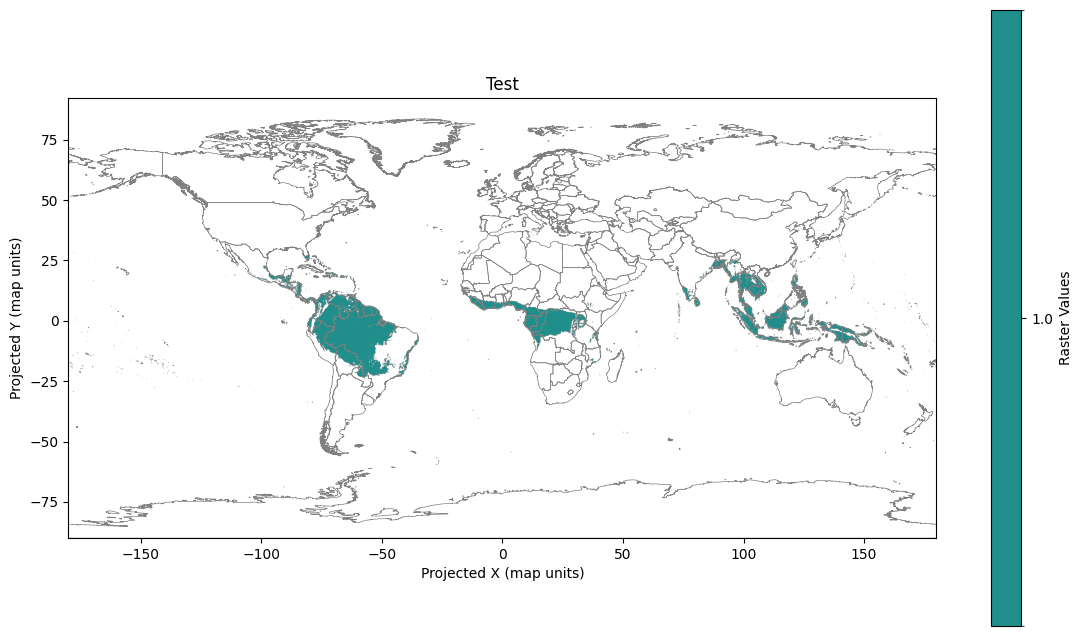

In [41]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Oil palm_rf.tif", "Test")

Raster has 1 unique values. Min: 1.00. Max: 1.00


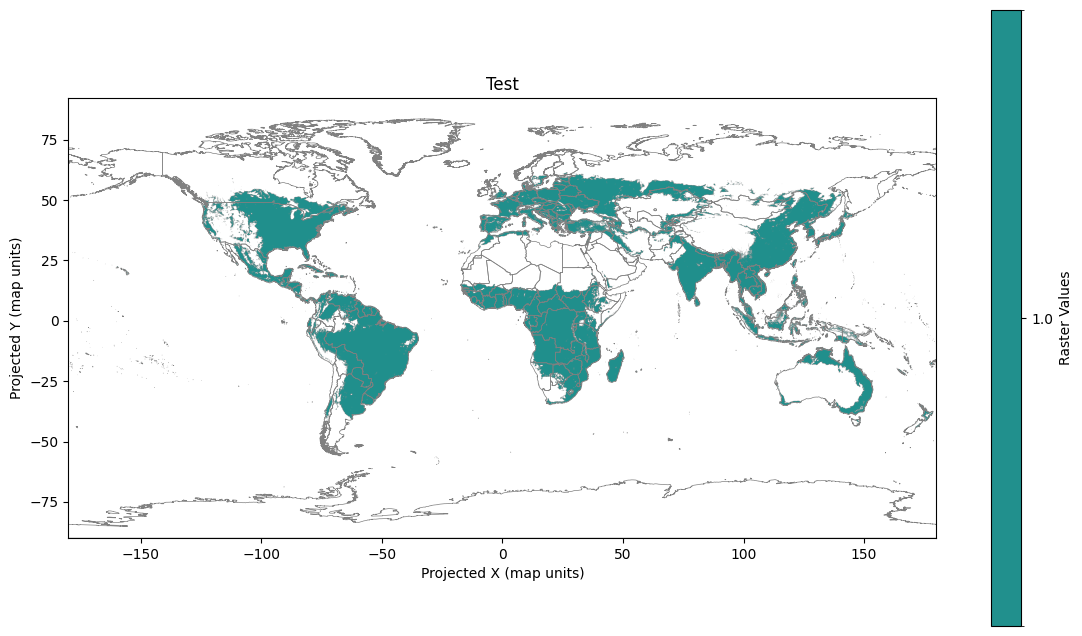

In [24]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Tomato_rf.tif", "Test")

They look good.

Adding the output files to the file inventory

In [42]:
df_lu_files = pl.DataFrame(output_rows)

In [33]:
df_lu_files.head(3)

crop_name,crop_practice_string,lu_file
str,str,str
"""Barley""","""irr_ron""","""C:\Users\loyola\OneDrive - Wor…"
"""Barley""","""irr_roff""","""C:\Users\loyola\OneDrive - Wor…"
"""Cabbage""","""irr""","""C:\Users\loyola\OneDrive - Wor…"


Adding it to sbtn_crops

In [43]:
sbtn_crops = sbtn_crops.join(
    other=df_lu_files,
    how="left",
    on = ["crop_name", "crop_practice_string"]
)

Fixing the column names as some crops - irrigation combinations were missing

In [44]:
sbtn_crops = sbtn_crops.drop("lu_file").rename({"lu_file_right":"lu_file"})

Exporting all this info

In [45]:
sbtn_crops.write_excel(data_path("crops","FAO_GAEZ", "crops_file_index.xlsx"), include_header=True)

## Yields FAO GAEZ Inventory

In [58]:
IRR_YLDS_LOOKUP = {
    "WSI": "Irrigated",
    "WSR": "Rainfed",
    "WST": "Total"
}

IRR_CODE_YLDS_LOOKUP = {
    "WSI": "irr",
    "WSR": "rf",
    "WST": "total"
}

In [73]:
ylds_crops_index = pl.read_excel(data_path("crops", "FAO_GAEZ", "YIELDS", "yields_crops_name_index.xlsx")).sort(by = "crop_code")

In [74]:
ylds_crops_index

crop_code,crop_name,index
str,str,i64
"""ALL""","""All crops""",34
"""BAN""","""Banana and plantain""",1
"""BRL""","""Barley""",2
"""CER""","""Cereals""",36
"""COC""","""Cocoa""",3
…,…,…
"""SUC""","""Sugarcane""",29
"""TEA""","""Tea and mate leaves""",30
"""TOB""","""Tobacco leaves""",31


In [76]:
output_rows = []
folder_path = data_path("crops", "FAO_GAEZ", "YIELDS")

for file in os.listdir(folder_path):
    if not file.lower().endswith(".tif"):  # skip not tif files
        continue

    filename = Path(file).stem  # dropping file extension
    file_path = str(folder_path / Path(file))
    parts = filename.split(".") # splitting based on "."
    if len(parts) < 2:
            continue
    
    crop_code = parts[-2].strip().upper() 
    irr_code = parts[-1].strip().upper()

    output_rows.append({
        "filename": file,
        "filepath": file_path,
        "crop_code": crop_code,
        "irr_code": irr_code,
        "irrigation_practice": IRR_YLDS_LOOKUP.get(irr_code),
        "irrigation_rothc_code": IRR_CODE_YLDS_LOOKUP.get(irr_code),
    })

df_ylds = pl.DataFrame(output_rows)

# Attach crop names
df_ylds = df_ylds.join(
     other=ylds_crops_index,
     on="crop_code",
     how="left"
)

In [77]:
df_ylds.head()

filename,filepath,crop_code,irr_code,irrigation_practice,irrigation_rothc_code,crop_name,index
str,str,str,str,str,str,str,i64
"""GAEZ-V5.RES06-YLD.BAN.WSI.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WSI""","""Irrigated""","""irr""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BAN.WSR.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WSR""","""Rainfed""","""rf""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BAN.WST.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WST""","""Total""","""total""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BRL.WSI.tif""","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""WSI""","""Irrigated""","""irr""","""Barley""",2
"""GAEZ-V5.RES06-YLD.BRL.WSR.tif""","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""WSR""","""Rainfed""","""rf""","""Barley""",2


Transforming to wide with 3 yields columns

In [78]:
df_ylds_wide = df_ylds.select(["crop_name", "irrigation_practice", "filepath"]).pivot(
    on = "irrigation_practice",
    index = "crop_name",
    values="filepath",
    aggregate_function="first"
)

In [79]:
df_ylds_wide.write_csv(data_path("crops","FAO_GAEZ","YIELDS","faogaez_yield_file_index.csv"), separator=";", include_header=True)

## Updated FAO GAEZ & SPAM RothC Inputs

### Creating the needed data inputs

Loading the inventory data file

In [80]:
annual_crops_prep_files = data_path("crops", "rothc_support","annual_crop_rothc_dataprep_inventory_FAOGAEZ.csv")
perm_crops_prep_files = data_path("crops", "rothc_support","permanent_crop_rothc_dataprep_inventory_FAOGAEZ.csv")

In [81]:
annuals_unique_data_prepared = cropcalcs.prepare_crop_scenarios_PET_PlantCover_only(annual_crops_prep_files)

Creating a unique list of rasters with different land use maps...

Preparing irrigation and plant cover data for Barley, irr_ron
Creating PET raster...
PET calculation completed for crop 'Barley' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Barley_irr_ron_irr_monthly.tif
Creating plant cover raster...
Plant cover raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Barley_irr_ron_pc_monthly.tif
Irrigation, PET, and plant cover rasters created for Barley, irr_ron!!!
Next!

Preparing irrigation and plant cover data for Cabbage, irr
Creating PET raster...
PET calculation completed for crop 'Cabbage' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\S

In [53]:
perm_unique_data_prepared = cropcalcs.prepare_crop_scenarios_PET_PlantCover_only(perm_crops_prep_files)

Creating a unique list of rasters with different land use maps...

Preparing irrigation and plant cover data for Banana, irr
Creating PET raster...
PET calculation completed for crop 'Banana' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Banana_irr_irr_monthly.tif
Creating plant cover raster...
Plant cover raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Banana_irr_pc_monthly.tif
Irrigation, PET, and plant cover rasters created for Banana, irr!!!
Next!

Preparing irrigation and plant cover data for Cocoa, irr
Creating PET raster...
PET calculation completed for crop 'Cocoa' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\

Exporting both these files

In [161]:
annuals_unique_data_prepared.to_csv(data_path("crops","rothc_support","FAO_GAEZ","annual_crops_FAO_GAEZ_data_path.csv"), sep=";", index=False)
perm_unique_data_prepared.to_csv(data_path("crops","rothc_support","FAO_GAEZ","perm_crops_FAO_GAEZ_data_path.csv"), sep=";", index=False)

### Running RothC

#### Annual Crops - Rainfed

In [14]:
annual_crop_rothc_rf_scenarios = "../data/crops/rothc_support/annual_crops_rothc_scenarios_rainfed_FAOGAEZ.xlsx"

In [16]:
rothc.run_rothc_crops_scenarios_from_excel(annual_crop_rothc_rf_scenarios, all_new_files=False, run_test=False)

Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 12, falling back to string


Annual crop - Barley - rf_ron already exists. Skipping...
Annual crop - Barley - rf_roff already exists. Skipping...
Annual crop - Cotton - rf already exists. Skipping...
Annual crop - Groundnut - rf already exists. Skipping...
Annual crop - Maize - rf_ron already exists. Skipping...
Annual crop - Maize - rf_roff already exists. Skipping...
Annual crop - Potato - rf already exists. Skipping...
Annual crop - Rapeseed - rf_ron already exists. Skipping...
Annual crop - Rapeseed - rf_roff already exists. Skipping...
Annual crop - Rice - rf already exists. Skipping...
Annual crop - Sorghum - rf_ron already exists. Skipping...
Annual crop - Sorghum - rf_roff already exists. Skipping...
Annual crop - Soybean - rf already exists. Skipping...
Annual crop - Sugar beet - rf already exists. Skipping...
Annual crop - Sunflower - rf already exists. Skipping...
Running Annual crop - Sweet potato - rf
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating b

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\data_loader.py:216: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  table = pl.DataFrame(THERMAL_CLIMATE_ROWS, schema=["id", "TC_Name", "TC_Group"])


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Sweet potato_rf_2030y_SOC.tif
Annual crop - Sweet potato - rf calculated. Continuing...


Annual crop - Tobacco - rf already exists. Skipping...
Annual crop - Tomato - rf already exists. Skipping...
Annual crop - Wheat - rf_ron already exists. Skipping...
Annual crop - Wheat - rf_roff already exists. Skipping...


Checking results...

In [17]:
soc_bar_rf_roff = project_root / "LEAFs/SOC/rasters/Barley_rf_roff_2021y_SOC.tif"
soc_bar_rf_ron = project_root / "LEAFs/SOC/rasters/Barley_rf_ron_2021y_SOC.tif"
sweetpot_rf = project_root / "LEAFs/SOC/rasters/Sweet potato_rf_2030y_SOC.tif"

In [18]:
mp.inspect_raster(sweetpot_rf)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Sweet potato_rf_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Sweet potato_rf in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 11.122314453125
  Max Value: 157.7855224609375
  Mean Value: 44.501060485839844
  Standard Deviation: 14.075793266296387

Band 2:
  Data Type: float32
  Min Value: 10.798866271972656
  Max Value: 146.9066925048828
  Mean Value: 40.456275939941406
  Standard Deviation: 13.28593921661377

Band 3:
  Data Type: float32


In [156]:
mp.inspect_raster(soc_bar_rf_ron)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Barley_rf_ron_2021y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 6
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Barley_rf_ron in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.972593784332275
  Max Value: 172.4505157470703
  Mean Value: 55.23243713378906
  Standard Deviation: 19.75246810913086

Band 2:
  Data Type: float32
  Min Value: 7.049479007720947
  Max Value: 165.91650390625
  Mean Value: 54.39997100830078
  Standard Deviation: 19.097597122192383

Band 3:
  Data Type: float32
  Min Va

Raster has 728,108 unique values. Min: 7.42. Max: 168.36
Using quantiles
All positives route (quantiles)


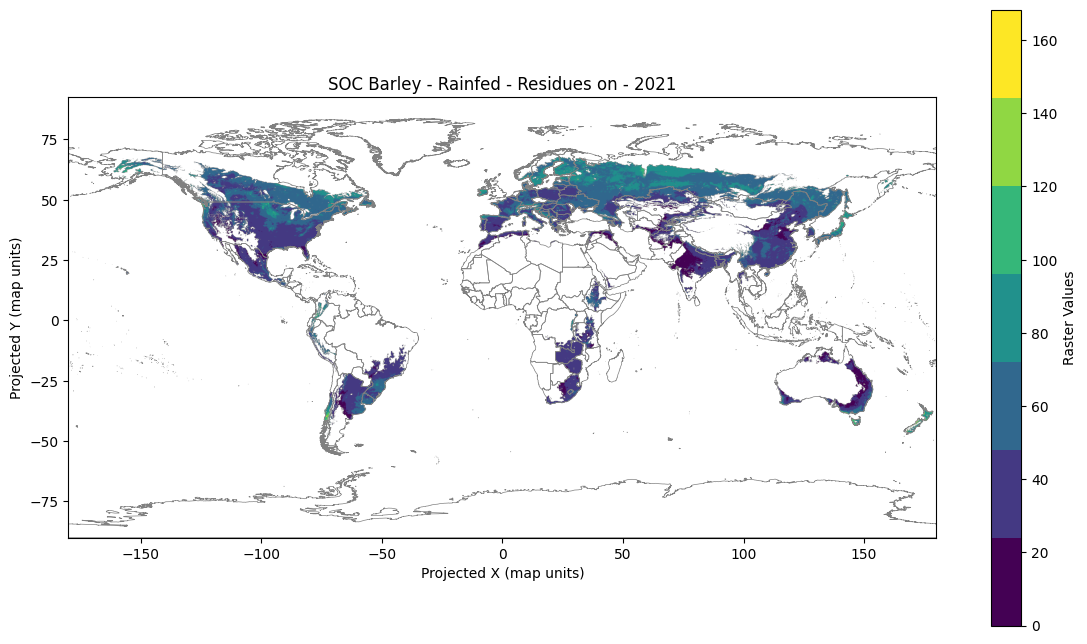

In [157]:
mp.plot_raster_on_world_extremes_cutoff(soc_bar_rf_ron, "SOC Barley - Rainfed - Residues on - 2021", perc_cutoff=0, quantiles=7, raster_band=6)

Raster has 821,389 unique values. Min: 5.24. Max: 158.77
Using quantiles
All positives route (quantiles)


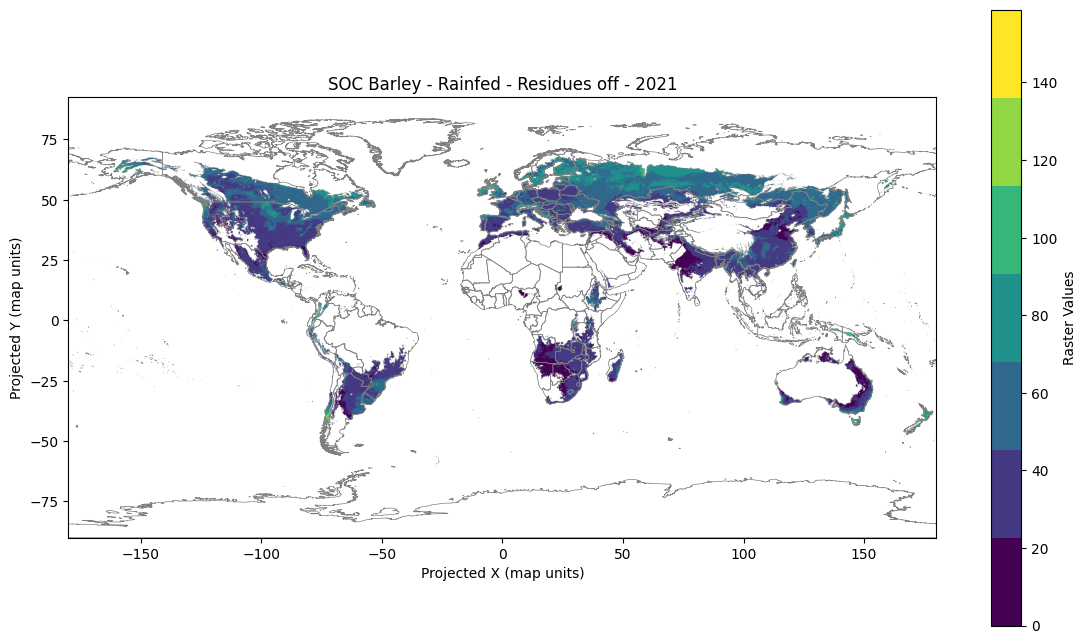

In [158]:
mp.plot_raster_on_world_extremes_cutoff(soc_bar_rf_roff, "SOC Barley - Rainfed - Residues off - 2021", perc_cutoff=0, quantiles=7, raster_band=6)

Raster has 480,419 unique values. Min: 7.07. Max: 157.62
Using quantile edges


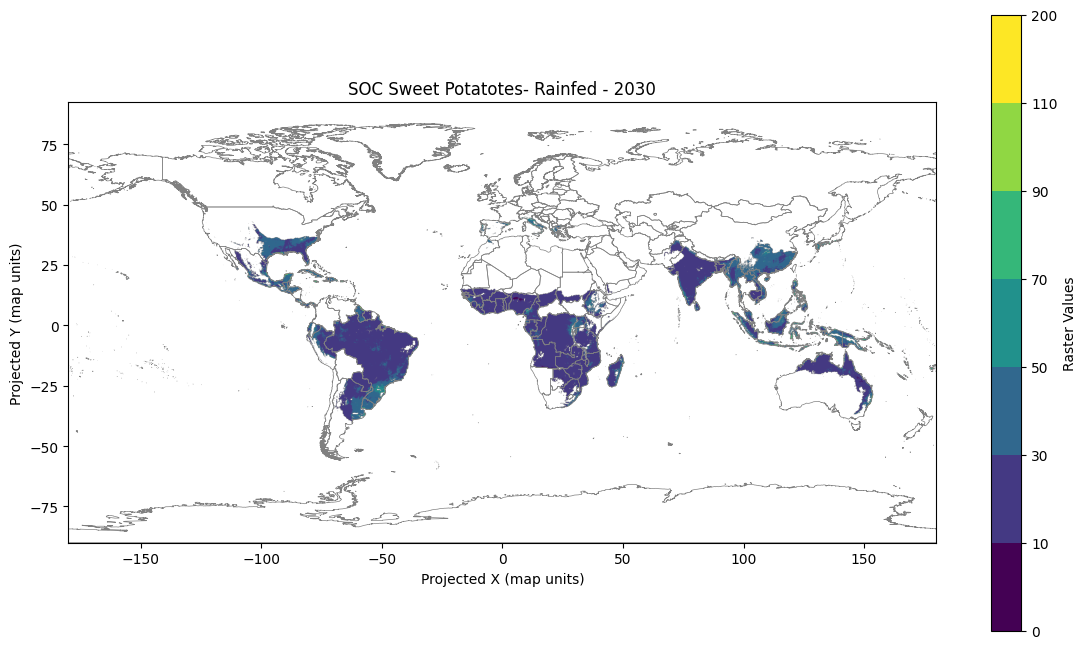

In [21]:
mp.plot_raster_on_world_extremes_cutoff(sweetpot_rf, "SOC Sweet Potatoes- Rainfed - 2030", perc_cutoff=0, quantiles=q_breaks, raster_band=15)

#### Annual Crops Irrigated

In [2]:
annual_crop_rothc_irr_scenarios = "../data/crops/rothc_support/annual_crops_rothc_scenarios_irrigated_FAOGAEZ.xlsx"

In [7]:
importlib.reload(cropcalcs)
importlib.reload(rothc)

Could not determine dtype for column 1, falling back to string


<module 'sbtn_leaf.RothC_Raster' from 'C:\\Users\\loyola\\OneDrive - World Wildlife Fund, Inc\\Documents\\203. Python projects\\SBTN_Test\\src\\sbtn_leaf\\RothC_Raster.py'>

In [3]:
rothc.run_rothc_crops_scenarios_from_excel(annual_crop_rothc_irr_scenarios, all_new_files=False, run_test=False)

Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 12, falling back to string


Annual crop - Barley - irr_ron already exists. Skipping...
Annual crop - Barley - irr_roff already exists. Skipping...
Annual crop - Cabbage - irr already exists. Skipping...
Annual crop - Carrot - irr already exists. Skipping...
Annual crop - Cotton - irr already exists. Skipping...
Annual crop - Groundnut - irr already exists. Skipping...
Annual crop - Maize - irr_ron already exists. Skipping...
Annual crop - Maize - irr_roff already exists. Skipping...
Annual crop - Onion - irr already exists. Skipping...
Annual crop - Potato - irr already exists. Skipping...
Annual crop - Rapeseed - irr_ron already exists. Skipping...
Annual crop - Rapeseed - irr_roff already exists. Skipping...
Annual crop - Rice - irr already exists. Skipping...
Annual crop - Sorghum - irr_ron already exists. Skipping...
Annual crop - Sorghum - irr_roff already exists. Skipping...
Annual crop - Soybean - irr already exists. Skipping...
Running Annual crop - Sugar beet - irr
    Loading environmental data...
    L

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\data_loader.py:216: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  table = pl.DataFrame(THERMAL_CLIMATE_ROWS, schema=["id", "TC_Name", "TC_Group"])


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Sugar beet_irr_2030y_SOC.tif
Annual crop - Sugar beet - irr calculated. Continuing...


Annual crop - Sunflower - irr already exists. Skipping...
Annual crop - Sweet potato - irr already exists. Skipping...
Annual crop - Tobacco - irr already exists. Skipping...
Annual crop - Tomato - irr already exists. Skipping...
Annual crop - Wheat - irr_ron already exists. Skipping...
Annual crop - Wheat - irr_roff already exists. Skipping...


In [4]:
sb_soc_results = project_root/'LEAFs/SOC/rasters/Sugar beet_irr_2030y_SOC.tif'

In [5]:
mp.inspect_raster(sb_soc_results)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Sugar beet_irr_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Sugar beet_irr in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.0228424072265625
  Max Value: 172.4505157470703
  Mean Value: 50.748695373535156
  Standard Deviation: 20.514854431152344

Band 2:
  Data Type: float32
  Min Value: 6.558168888092041
  Max Value: 166.2670135498047
  Mean Value: 50.393314361572266
  Standard Deviation: 19.540935516357422

Band 3:
  Data Type: float32

Checking test results

In [165]:
soc_bar_irr_roff = project_root / "LEAFs/SOC/rasters/Barley_irr_roff_2021y_SOC.tif"
soc_bar_irr_ron = project_root / "LEAFs/SOC/rasters/Barley_irr_ron_2021y_SOC.tif"

In [166]:
mp.inspect_raster(soc_bar_irr_roff)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Barley_irr_roff_2021y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 6
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Barley_irr_roff in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.0228424072265625
  Max Value: 172.4505157470703
  Mean Value: 48.46479034423828
  Standard Deviation: 21.792015075683594

Band 2:
  Data Type: float32
  Min Value: 5.632936954498291
  Max Value: 165.36843872070312
  Mean Value: 45.618717193603516
  Standard Deviation: 21.53496742248535

Band 3:
  Data Type: float32

In [167]:
mp.inspect_raster(soc_bar_irr_ron)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Barley_irr_ron_2021y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 6
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Barley_irr_ron in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.0228424072265625
  Max Value: 172.4505157470703
  Mean Value: 48.46479034423828
  Standard Deviation: 21.792015075683594

Band 2:
  Data Type: float32
  Min Value: 6.748688697814941
  Max Value: 166.2102813720703
  Mean Value: 48.366966247558594
  Standard Deviation: 21.122203826904297

Band 3:
  Data Type: float32
 

Raster has 943,838 unique values. Min: 4.68. Max: 158.77
Using quantiles
All positives route (quantiles)


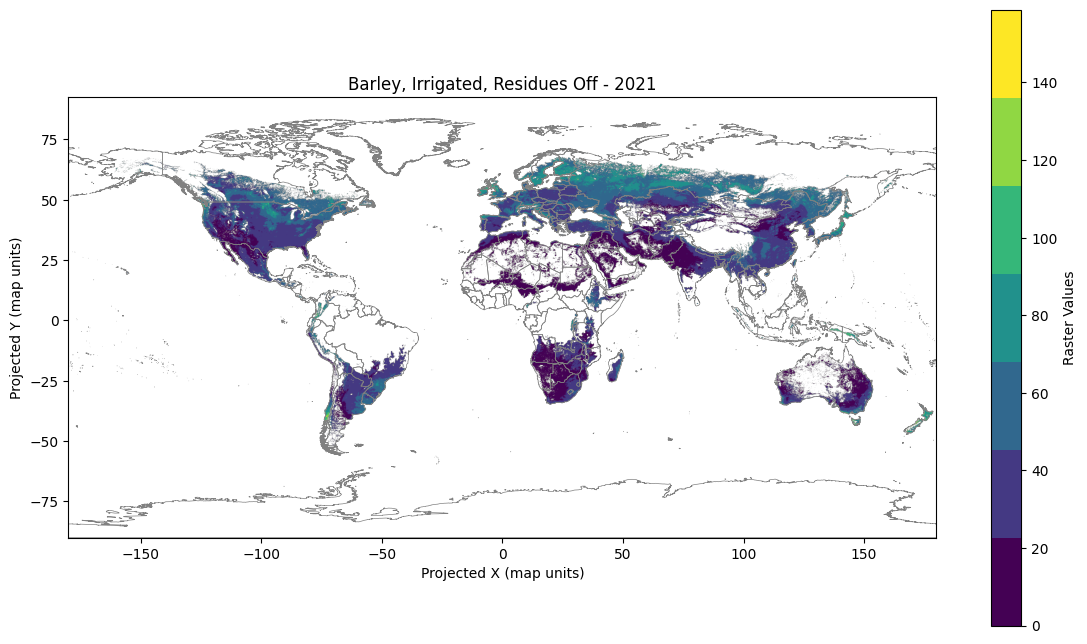

In [170]:
mp.plot_raster_on_world_extremes_cutoff(soc_bar_irr_roff, "Barley, Irrigated, Residues Off - 2021", perc_cutoff=0, quantiles = 7, raster_band = 6)

Raster has 813,084 unique values. Min: 7.15. Max: 176.31
Using quantiles
All positives route (quantiles)


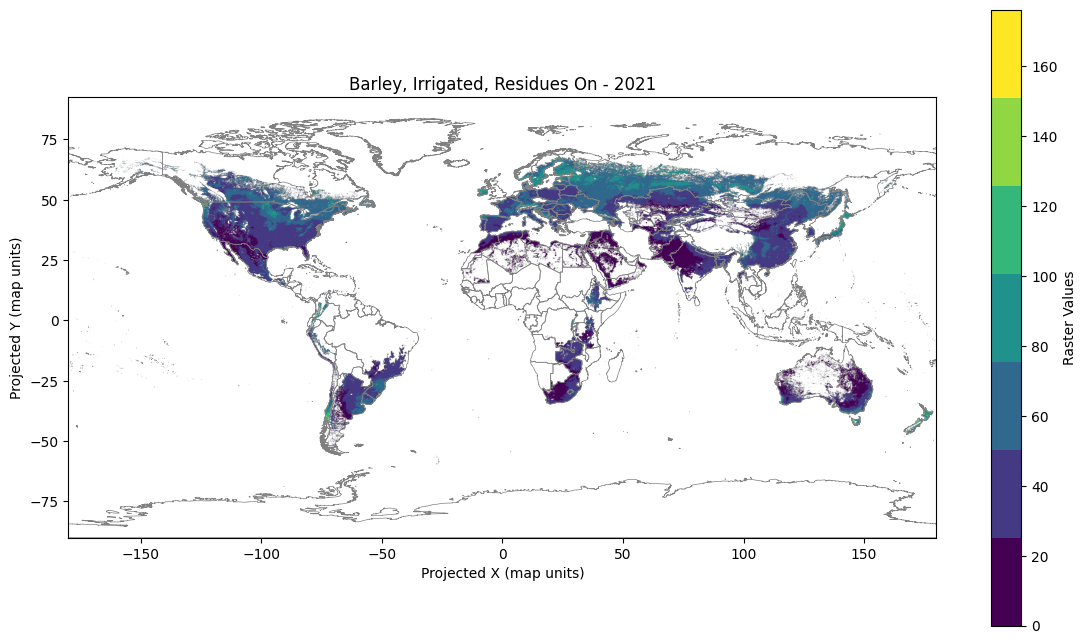

In [171]:
mp.plot_raster_on_world_extremes_cutoff(soc_bar_irr_ron, "Barley, Irrigated, Residues On - 2021", perc_cutoff=0, quantiles = 7, raster_band = 6)

In [184]:
Barley_test_rasters = [soc_bar_irr_roff, soc_bar_irr_ron, soc_bar_rf_roff, soc_bar_rf_ron]
Barley_titles=["Barley, Irrigated, Residues Off", "Barley, Irrigated, Residues On", "Barley, Rainfed, Residues Off", "Barley, Rainfed, Residues On"]

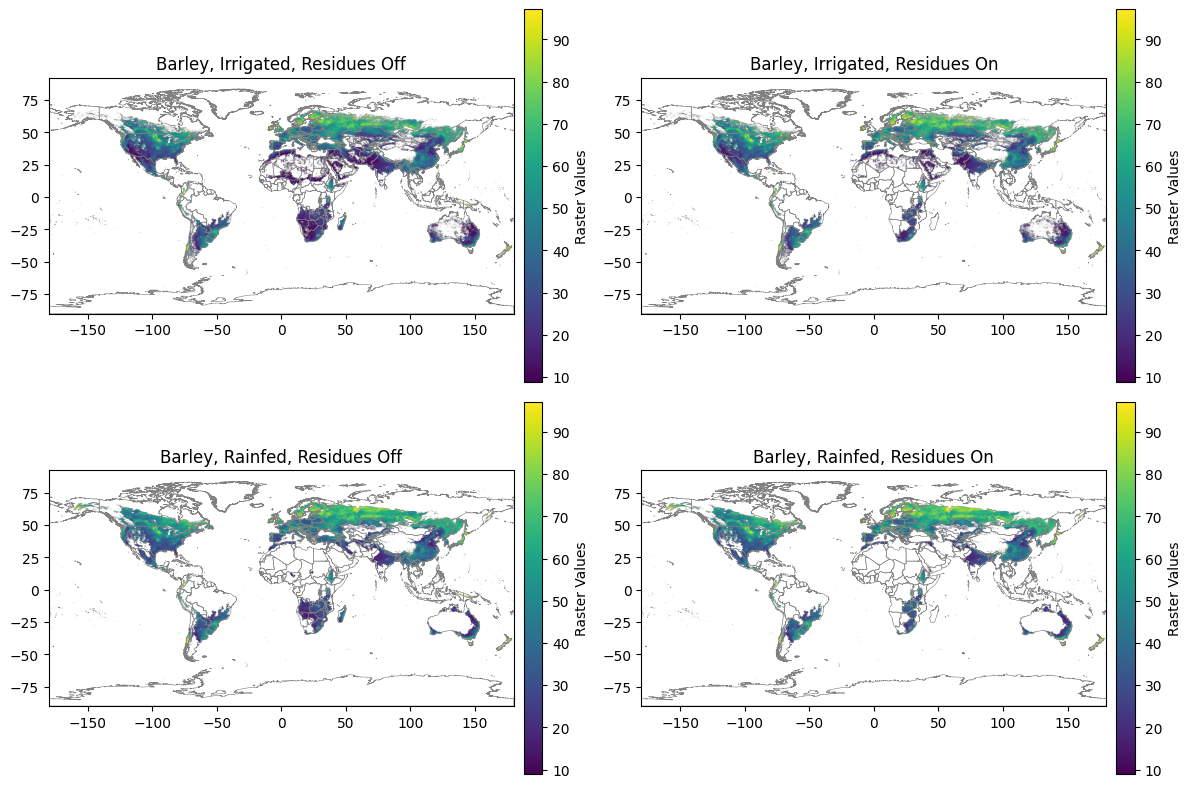

(<Figure size 1200x800 with 8 Axes>,
 array([[<Axes: title={'center': 'Barley, Irrigated, Residues Off'}>,
         <Axes: title={'center': 'Barley, Irrigated, Residues On'}>],
        [<Axes: title={'center': 'Barley, Rainfed, Residues Off'}>,
         <Axes: title={'center': 'Barley, Rainfed, Residues On'}>]],
       dtype=object))

In [185]:
mp.plot_n_rasters_on_world_extremes_cutoff(Barley_test_rasters, 
                                           titles=Barley_titles,
                                           n_rows=2, n_cols=2, share_color_scale=True, raster_band=6, perc_cutoff=1)

#### Sugar beet issues
For some reason sugar beet is producing empty results, so checking the inputs to see what's happening.

In [58]:
sb_irr_lu = project_root /"data/land_use/FAO_GAEZ/lu_gaez_Sugar beet_irr.tif"
sb_irr_ylds = project_root /"data/crops/FAO_GAEZ/YIELDS/GAEZ-V5.RES06-YLD.SUB.WSI.tif"
sb_rf_ylds = project_root /"data/crops/FAO_GAEZ/YIELDS/GAEZ-V5.RES06-YLD.SUB.WSR.tif"
sb_all_ylds = project_root /"data/crops/FAO_GAEZ/YIELDS/GAEZ-V5.RES06-YLD.SUB.WST.tif"


Raster has 1 unique values. Min: 1.00. Max: 1.00


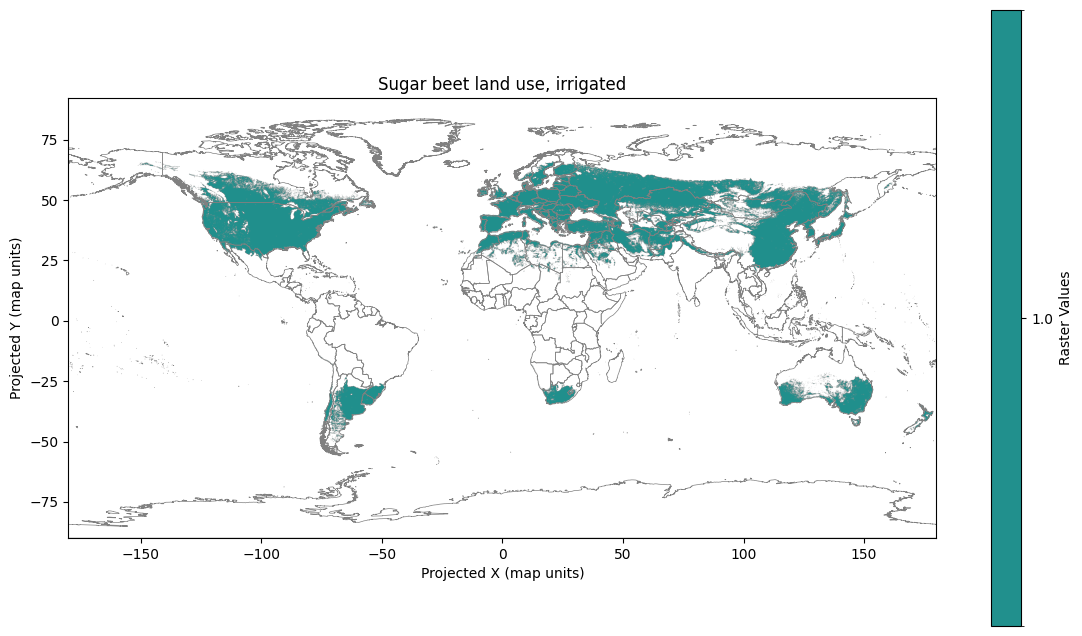

In [57]:
mp.plot_raster_on_world_extremes_cutoff(sb_irr_lu, "Sugar beet land use, irrigated", perc_cutoff = 0)

Raster has 87,224 unique values. Min: 2.92. Max: 207.88
Not using quantiles
All positives route (continuous)


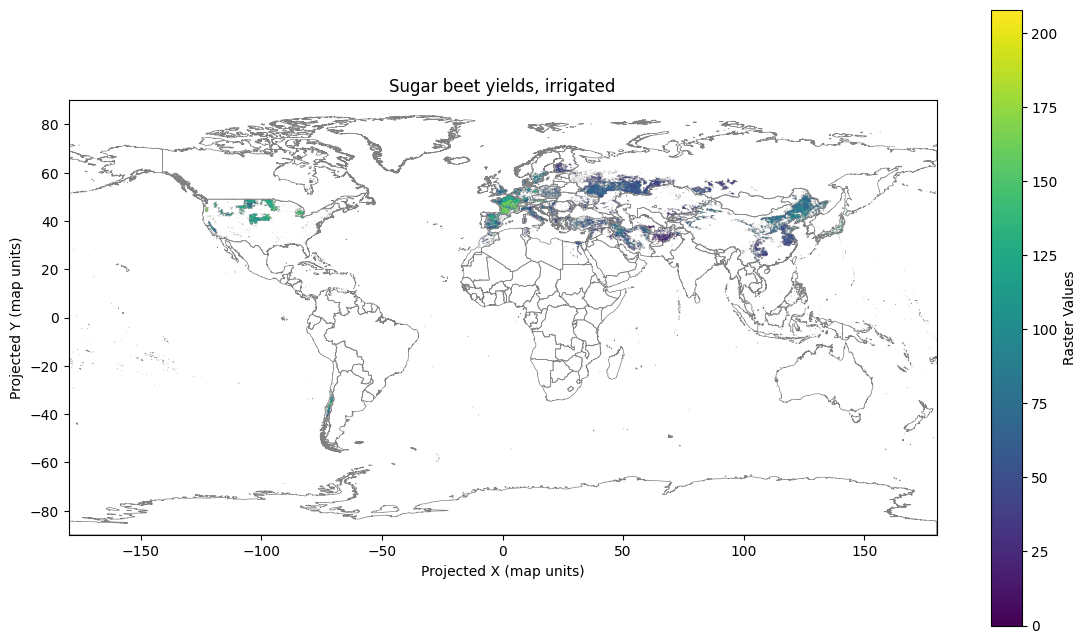

In [59]:
mp.plot_raster_on_world_extremes_cutoff(sb_irr_ylds, "Sugar beet yields, irrigated", perc_cutoff = 0)

Raster has 96,638 unique values. Min: 0.85. Max: 137.05
Not using quantiles
All positives route (continuous)


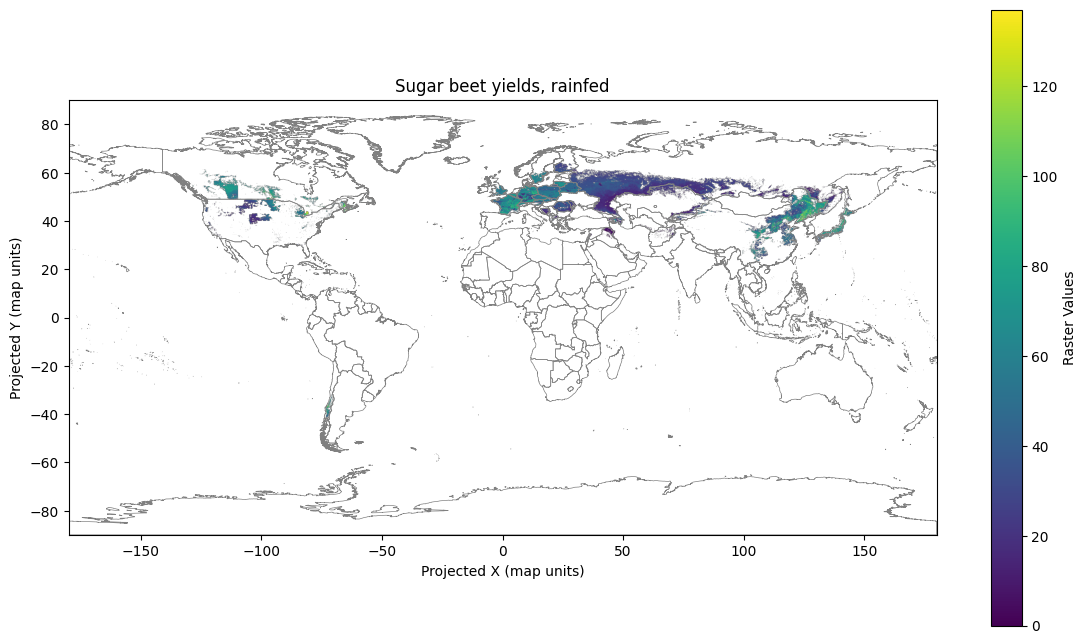

In [60]:
mp.plot_raster_on_world_extremes_cutoff(sb_rf_ylds, "Sugar beet yields, rainfed", perc_cutoff = 0)

Raster has 188,529 unique values. Min: 0.96. Max: 195.60
Not using quantiles
All positives route (continuous)


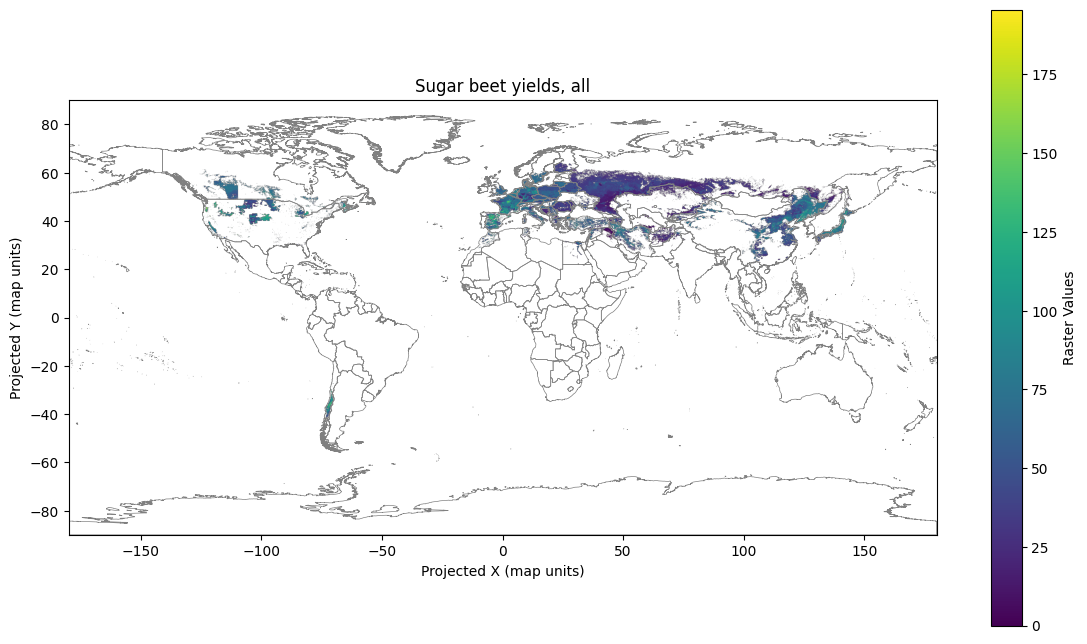

In [ ]:
mp.plot_raster_on_world_extremes_cutoff(sb_all_ylds, "Sugar beet yields, all", perc_cutoff = 0)

In [63]:
sb_pet = project_root / "data/crops/rothc_support/FAO_GAEZ/Sugar beet_irr_pet_monthly.tif"
sb_pc = project_root / "data/crops/rothc_support/FAO_GAEZ/Sugar beet_irr_pc_monthly.tif"
sb_irr = project_root / "data/crops/rothc_support/FAO_GAEZ/Sugar beet_irr_irr_monthly.tif"

Raster has 640,805 unique values. Min: 0.00. Max: 459.60
Not using quantiles
All positives route (continuous)


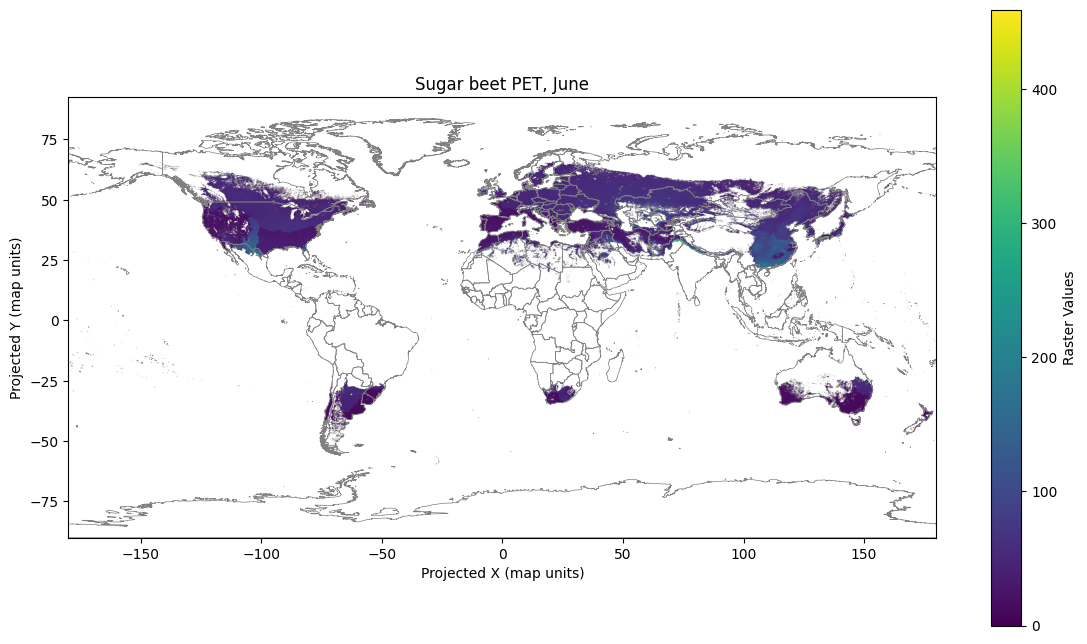

In [70]:
mp.plot_raster_on_world_extremes_cutoff(sb_pet, "Sugar beet PET, June", perc_cutoff = 0, raster_band = 5)

Raster has 2 unique values. Min: 0.00. Max: 1.00


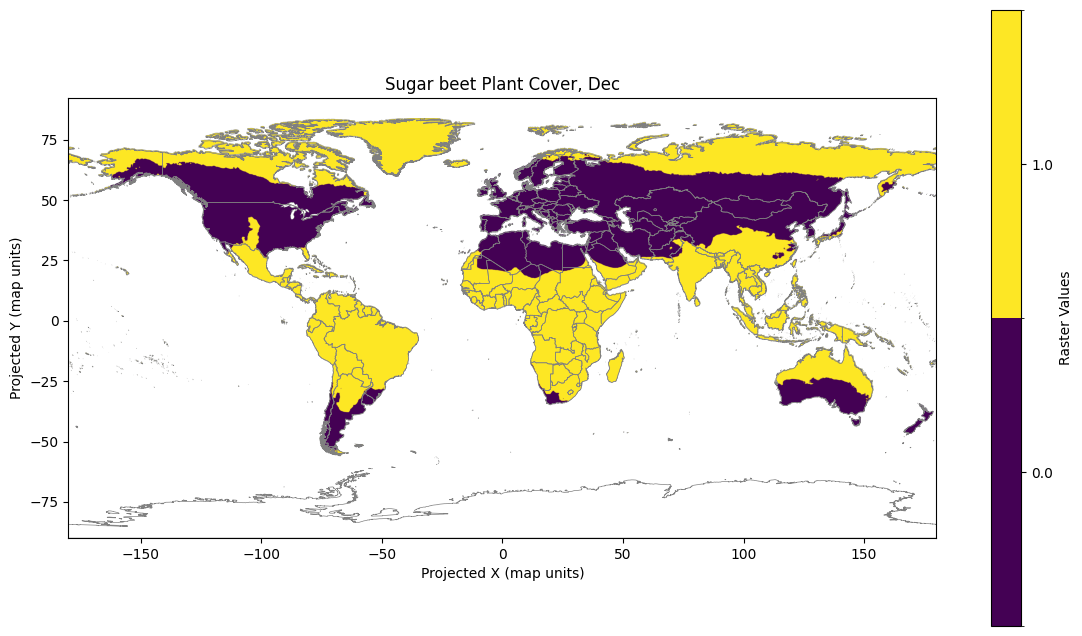

In [68]:
mp.plot_raster_on_world_extremes_cutoff(sb_pc, "Sugar beet Plant Cover, Dec", perc_cutoff = 0, raster_band=11)

Raster has 11,640 unique values. Min: 0.00. Max: 296.22
Not using quantiles
All positives route (continuous)


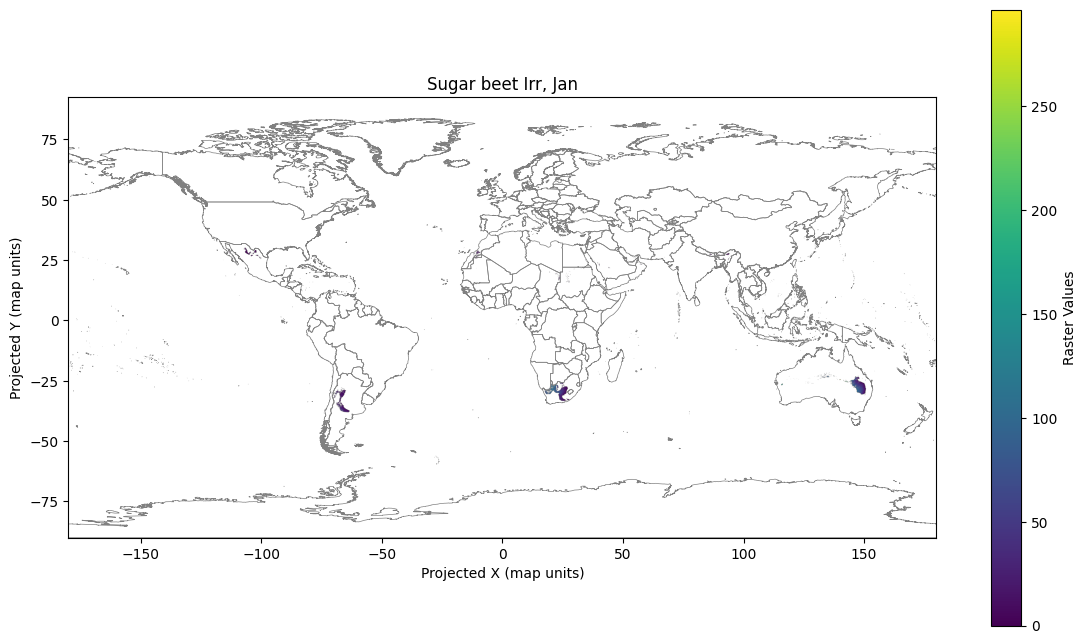

In [66]:
mp.plot_raster_on_world_extremes_cutoff(sb_irr, "Sugar beet Irr, Jan", perc_cutoff = 0)

#### Permanent crops

In [2]:
perm_crop_rothc_scenarios = "../data/crops/rothc_support/permcrops_baseline_rothc_scenarios_FAOGAEZ.xlsx"

In [5]:
rothc.run_rothc_crops_scenarios_from_excel(perm_crop_rothc_scenarios, all_new_files=False, run_test=False)

Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 11, falling back to string


Permanent crop - Apple - irr already exists. Skipping...
Permanent crop - Banana - irr already exists. Skipping...
Permanent crop - Cocoa - irr already exists. Skipping...
Permanent crop - Coconut - irr already exists. Skipping...
Permanent crop - Coffee - irr already exists. Skipping...
Permanent crop - Grapes - irr already exists. Skipping...
Permanent crop - Oil palm - irr already exists. Skipping...
Permanent crop - Olive - irr already exists. Skipping...
Permanent crop - Orange - irr already exists. Skipping...
Permanent crop - Apple - rf already exists. Skipping...
Running Permanent crop - Banana - rf
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for permanent Banana


C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\data_loader.py:216: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  table = pl.DataFrame(THERMAL_CLIMATE_ROWS, schema=["id", "TC_Name", "TC_Group"])


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Banana_rf_2030y_SOC.tif
Permanent crop - Banana - rf calculated. Continuing...


Running Permanent crop - Cocoa - rf
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for permanent Cocoa


...

    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Orange_rf_2030y_SOC.tif
Permanent crop - Orange - rf calculated. Continuing...


Running Permanent crop - Sugarcane - irr
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for permanent Sugarcane


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Sugarcane_irr_2030y_SOC.tif
Permanent crop - Sugarcane - irr calculated. Continuing...


Running Permanent crop - Sugarcane - rf
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for permanent Sugarcane


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Sugarcane_rf_2030y_SOC.tif
Permanent crop - Sugarcane - rf calculated. Continuing...




Checking results...

In [192]:
soc_app_irr = soc_raster_folder/"Apple_irr_2021y_SOC.tif"
soc_ban_irr = soc_raster_folder/"Banana_irr_2021y_SOC.tif"

In [193]:
mp.inspect_raster(soc_app_irr)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Apple_irr_2021y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 6
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC model results for year 2030 for Apple, irrigated
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 7.7331671714782715
  Max Value: 166.87579345703125
  Mean Value: 45.55247116088867
  Standard Deviation: 17.2567138671875

Band 2:
  Data Type: float32
  Min Value: 8.30196762084961
  Max Value: 158.01644897460938
  Mean Value: 42.66170883178711
  Standard Deviation: 16.965343475341797

Band 3:
  Data Type: float32
  Min Value:

In [194]:
mp.inspect_raster(soc_ban_irr)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Banana_irr_2021y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 6
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC model results for year 2030 for Banana, irrigated
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 7.612054824829102
  Max Value: 144.9335479736328
  Mean Value: 39.155235290527344
  Standard Deviation: 16.11948585510254

Band 2:
  Data Type: float32
  Min Value: 7.383039951324463
  Max Value: 142.39366149902344
  Mean Value: 37.38807678222656
  Standard Deviation: 14.874943733215332

Band 3:
  Data Type: float32
  Min Val

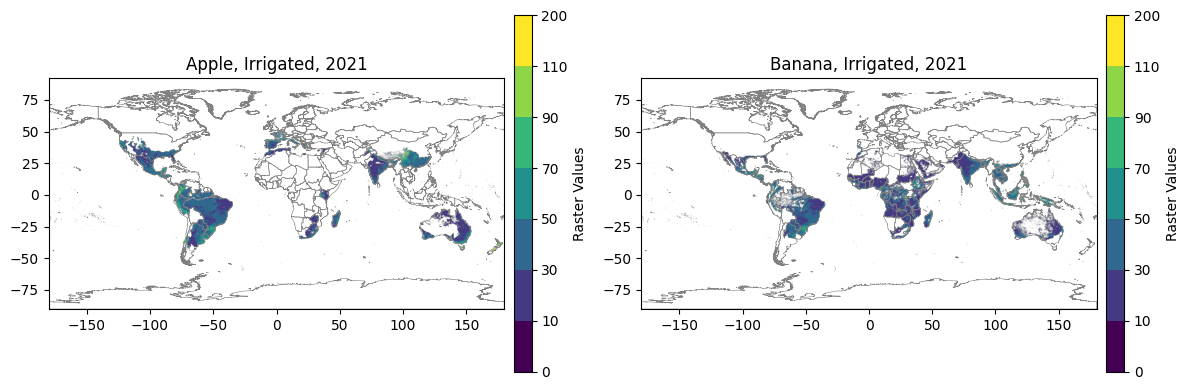

(<Figure size 1200x400 with 4 Axes>,
 array([[<Axes: title={'center': 'Apple, Irrigated, 2021'}>,
         <Axes: title={'center': 'Banana, Irrigated, 2021'}>]],
       dtype=object))

In [198]:
mp.plot_n_rasters_on_world_extremes_cutoff([soc_app_irr, soc_ban_irr], 
                                           titles=["Apple, Irrigated, 2021", "Banana, Irrigated, 2021"],
                                           n_rows=1, n_cols=2, share_color_scale=True, raster_band=6, perc_cutoff=0, quantiles=q_breaks)

## Regional Averages
Now that the new SOC values have been calculated, new regional averages need to be calculated. The filtering method has been updated to match the one just applied for yields.

In [36]:
sugarbeet = project_root/"LEAFs/SOC/rasters/test/Sugarbeet_irr_2030y_SOC.tif"

In [52]:
mp.inspect_raster(sugarbeet)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\test\Sugarbeet_irr_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Sugar beet_irr in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.0228424072265625
  Max Value: 172.4505157470703
  Mean Value: 50.748695373535156
  Standard Deviation: 20.514854431152344

Band 2:
  Data Type: float32
  Min Value: nan
  Max Value: nan
  Mean Value: nan
  Standard Deviation: nan

Band 3:
  Data Type: float32
  Min Value: nan
  Max Value: nan
  Mean Value: nan
 

Raster has 654,879 unique values. Min: 12.63. Max: 99.44
Not using quantiles
All positives route (continuous)


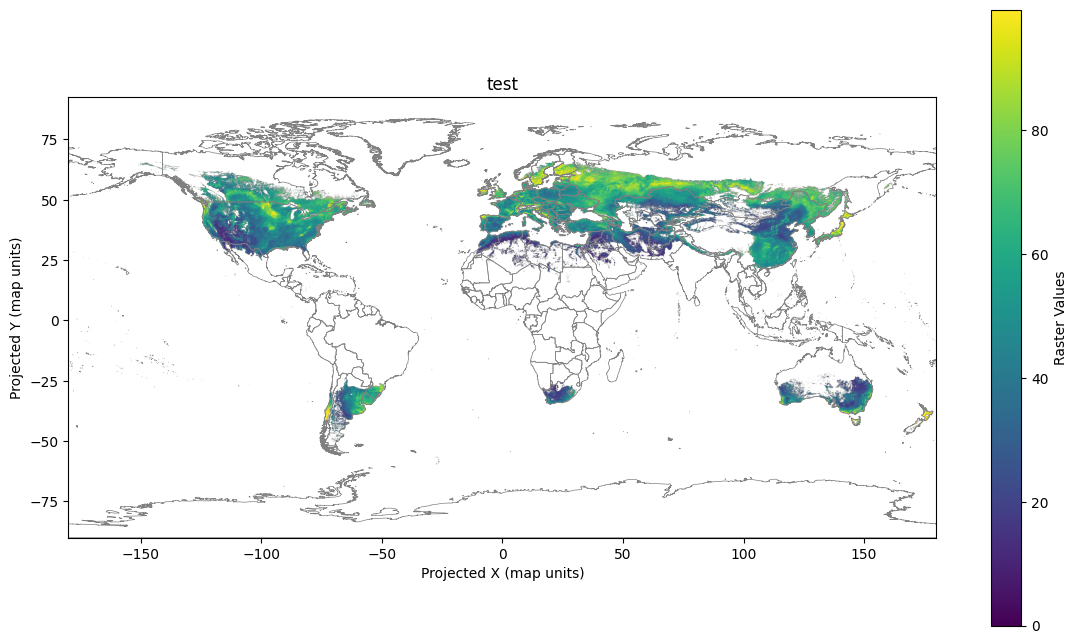

In [37]:
mp.plot_raster_on_world_extremes_cutoff(sugarbeet, "test")

### Countries

In [44]:
# Inputs that stay the same
input_folder = soc_raster_folder/"test"
output_folder = project_root/"LEAFs/SOC/"
cf_name = "SOC_2030"
cf_unit = "t C/ha"
reset_gpck = True

In [45]:
# Inputs that change by area type
area_type = "country"
layer_name = "soc_leaf_country"
corrected_shp = gpd.read_file(project_root/'data/CountryLayers/Country_Level0/g2015_2014_0_dissolved.shp')
master_key = "ADM0_NAME"
result_key = "country"

In [50]:
importlib.reload(mc)

<module 'sbtn_leaf.map_calculations' from 'C:\\Users\\loyola\\OneDrive - World Wildlife Fund, Inc\\Documents\\203. Python projects\\SBTN_Test\\src\\sbtn_leaf\\map_calculations.py'>

In [51]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    gpckg_name="TEST_SOC_2030_country_v2",
    input_folder = str(input_folder),
    output_folder = str(output_folder),
    layer_name=layer_name,
    master_gdf=corrected_shp,           # e.g., countries, subcountries, or ecoregions
    master_key=master_key,              # or 'ISO_A3', 'ADM1_NAME', 'ECO_NAME'
    result_key=result_key,              # must match the column emitted by your calc gdf
    input_raster_key_startswith=None,
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=dict(raster_band = 15, outlier_method="log1p_win", q_low = 0.01, q_high = 0.99),     # Chooses the raster band. Due to outliers in crops, setting it to windsorize, replacing all values outside 1, 99 percentiles with those values.
    reset_gpkg=reset_gpck,
    run_test=True                             # Use run test to run the first 3 files
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2026-03-02 18:47:43,654 - INFO - Building 'soc_leaf_country' from rasters in c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\test into c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC (c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOCTEST_SOC_2030_country_v2.gpkg)



Processing rasters (soc_leaf_country):   0%|          | 0/2 [00:00<?, ?raster/s]

2026-03-02 18:47:53,603 - INFO - Calculating SOC_2030 for Sugarbeet_irr_2030y_SOC...
Calculating SOC_2030 for Sugarbeet_irr_2030y_SOC...


No valid data for %s. Skipping... Mozambique
No valid data for %s. Skipping... Mauritius
No valid data for %s. Skipping... Malawi
No valid data for %s. Skipping... Mayotte
No valid data for %s. Skipping... Rwanda
No valid data for %s. Skipping... Somalia
No valid data for %s. Skipping... Zambia
No valid data for %s. Skipping... Kenya
No valid data for %s. Skipping... Madagascar
No valid data for %s. Skipping... Réunion
No valid data for %s. Skipping... South Sudan
No valid data for %s. Skipping... Seychelles
No valid data for %s. Skipping... United Republic of Tanzania
No valid data for %s. Skipping... Uganda
No valid data for %s. Skipping... Zimbabwe
No valid data for %s. Skipping... Ilemi triangle
No valid data for %s. Skipping... Europa Island
No valid data for %s. Skipping... Ethiopia
No valid data for %s. Skipping... Eritrea
No valid data for %s. Skipping... Djibouti
No valid data for %s. Skipping... Comoros
No valid data for %s. Skipping... Burundi
No valid data for %s. Skipping.

KeyError: 'country'

In [23]:
gdf_test_values = gpd.read_file(gpkg_path, layer=layer_name)
gdf_test_values.sort_values(by="cf", ascending=False).head()

,ADM0_NAME,flow_name,cf,cf_median,cf_std,_source_file
10055,Iceland,NEEV_Boreal moist_2030y_SOC,757.844971,765.638306,54.876278,NEEV_Boreal moist_2030y_SOC.tif
10203,United States of America,NEEV_Boreal moist_2030y_SOC,703.245850,696.835938,102.361382,NEEV_Boreal moist_2030y_SOC.tif
943,Iceland,BRDC_Boreal moist_2030y_SOC,688.742493,694.697693,44.970459,BRDC_Boreal moist_2030y_SOC.tif
10146,Russian Federation,NEEV_Boreal moist_2030y_SOC,673.695129,683.818787,68.782433,NEEV_Boreal moist_2030y_SOC.tif
839,Argentina,BRDC_Boreal moist_2030y_SOC,655.003601,655.003601,0.000000,BRDC_Boreal moist_2030y_SOC.tif


In [25]:
gdf_test_geometries = gpd.read_file(gpkg_path, layer="geometry_layer")
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ADM0_NAME")

In [26]:
test = gdf_test[gdf_test["flow_name"]=="Potato_rf_2030y_SOC"]

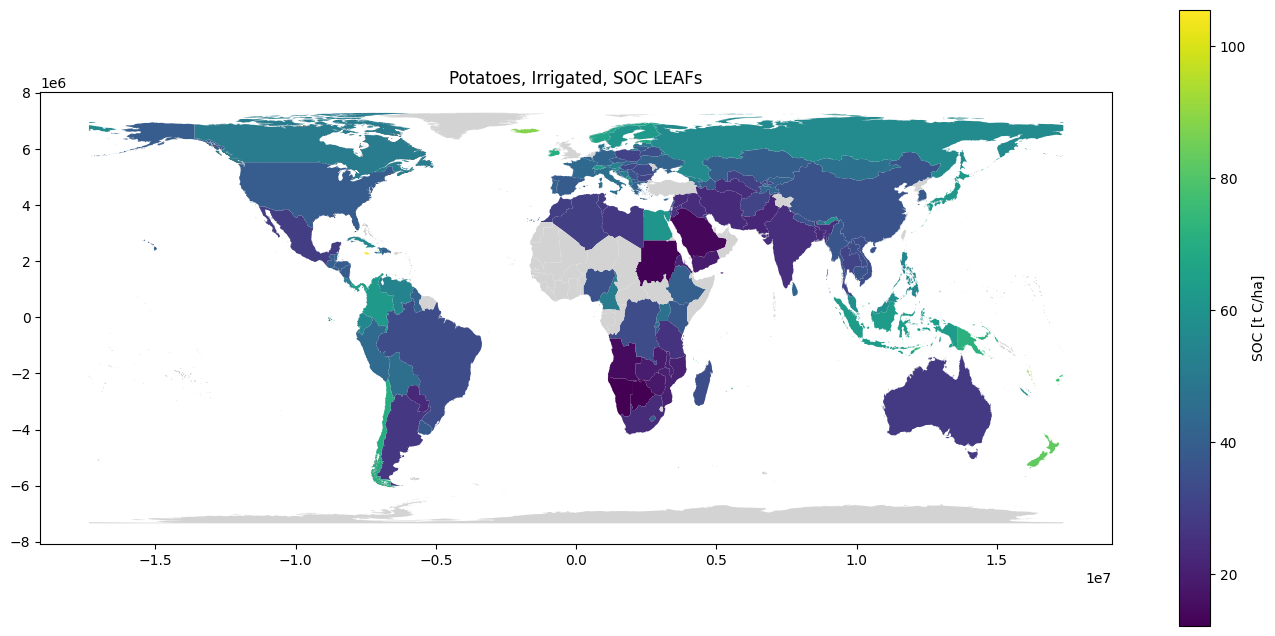

In [28]:
fig, ax = plt.subplots(figsize=(14, 8)) 
test.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "SOC [t C/ha]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("Potatoes, Irrigated, SOC LEAFs")
plt.tight_layout() 
plt.show()